*created 24 Feb 2026, Julian Mak (whatever with copyright, do what you want with this)

### As part of material for OCES 5303 "AI and Machine Learning in Ocean Science" delivered at HKUST

For the latest version of the material, go to the public facing [GitHub](https://github.com/julianmak/OCES5303_ML_ocean) page.

---
# 10. Fourier Neural Operators (FNOs)

The main keyword here is the ***operator*** part. If we think of data as points in some space (encoded as vectors), then a neural network learns the mapping between input vectors in one space to output vectors in another space (but sometimes could be the same space). Three examples would be:

* classification: cats and dogs images (in our $64^2$d space) to labels (two points of a 1d space)
* dimension reduction: cats and dogs images being compressed to $n$-d space, where $n$ is however many number of eigencat EOFs we want to keep
* regression: top half of cat face (in our $64\times32$d space) to bottom half of cat face (in another or the same $64\times32$d space)

The main thing is neural networks is a best fit map between **vectors** that you provide not necessarily with regard for the space of interest. What you would also like is that map to be a good approximation of the underlying finite (but high) dimension (sub)space also, because then you have generalisability. Of couse in practice you don't really have that, and there are things you could do to try and improve it.

***Operators*** refer instead to maps between infinite dimension **spaces**. So the aim here is to learn the mapping between spaces, and you hope that map when restricted to appropriate subspaces (e.g. the high but finite dimensional feature space mentioned above) would have skill, the idea being that there is generalisability already because you learn the more general object. In practice you can't really do things numerically in a infinite dimension space, and instead you have to have a finite representation of that infinite dimension space, which may be easy or hard depending on the space and/or nature of the problem you are dealing with. 

For a fairly wide class of functions of interest, the ***Fourier*** representation is a particularly good one, and to me at least that is essentially the coarse idea of FNOs: take your data, transform it into a (finite) Fourier representation, learn the mappings within the Fourier representation, then convert it back to real space. 

This is similar but in contrast to convolutions layers (cf. `05_CNNs`), where the transformations are done in the underlying real space, but you need to specify the kernel size (and strides etc.); indeed one could argue FNOs are CNNs with full domain kernel size, for reasons to be argued later.

Given the key part the Fourier representation plays I'm going to do a quick recap of this and the associated numerics first using the commands in `torch`; if you know about these things already you can safely skip to the ***Fourier layer*** part. Going to do three examples here, all of which we have encountered before.

> ## Key Objective(s)
> 0. Recap of Fourier analysis (can skip if familiar enough)
> 1. Structure of Fourier layers, and comparison with convolution layers
> 2. Example of 1d FNO on time-varying PDEs
> 3. Example of 2d FNO on image regression

> NOTE: The examples I made below are ok in terms of speed (5 to 10 mins on my laptop?), but if you have access to a GPU then I would use that, because I found it to make quite a significant difference in speed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Set the device to be used
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

---
## a) Idea and structure of a FNO

### Recap: Fourier analysis

(Can skip this if you know about Fourier analysis already.)

When we deal with vectors in general there are many representations of the vector we can choose, and we may want a particularly convenient/clean one to deal with. For example, we may have
\begin{equation*}
    \mathrm{color} = (\mathrm{Red}, \mathrm{Green}, \mathrm{Blue}).
\end{equation*}
Every colour is expressed uniquely by intensity in the red, green and blue channel; this part gives you a ***basis*** for the colour space in terms of RGB. We would assume the RGB representation leads to no information overlap between the channels, and thus the basis is constructed to be ***orthogonal***.

> NOTE: The above assumes you can meaningfully talk about an ***inner product vector space*** structure for colours, and here I just assume you can for convenience. In reality colour perception is not so straightforward, but assuming the above structure is at least convenient.

The thing is that there is nothing stopping me doing
\begin{equation*}
    \mathrm{color} = (\mathrm{Reeen}, \mathrm{GrReB}, \mathrm{dlue})
\end{equation*}
or some other combination thereof. It is still a basis as long as I still have a unique representation if I can't make one channel from a linear combination of the others. The resulting choice of basis may not necessarily be orthogonal, and so may not be overly convenient to work with. Not having an orthogonal basis then is like (but is not exactly the same as) having ***confounding variables***, e.g. "productivity" in terms of "temperature" and "nutrient" ("nutrient" could be a function of "temperature" and there could redundant information). 

Either way, having an orthogonal basis of the data is useful. PCAs and EOFs for example essentially construct an orthogonal basis based on the data. It doesn't necessarily get rid of the confounding factors though, because it is simply trying to build a convenient representation of data.

For a wide class of real functions $f(x)$ we can represent it uniquely as
\begin{equation*}
    f(x) = a_0 + \sum_{k=1}^\infty a_k \cos(kx) + b_k \sin(kx),
\end{equation*}
and it turns out in this case cosines and sines form an orthgonal basis for the relevant function space. This is more obvious if you know some complex analysis: we have by de Moivre's theorem that
\begin{equation*}
    \mathrm{e}^{\mathrm{i}kx} = \cos(kx) + \mathrm{i}\sin(kx)
\end{equation*}
where $\mathrm{i} = \sqrt{-1}$ is the imaginary number, so an equivalent representation of the above is
\begin{equation*}
    f(x) = \mathrm{Real}\left(\sum_{k=-\infty}^\infty c_k \mathrm{e}^{\mathrm{i}kx}\right),
\end{equation*}
where $c_k$ are complex numbers. If you multiply by $\mathrm{e}^{-\mathrm{i}k'x}$ and integrate over one period ($[0, 2\pi]$ for simplicity), then everything integrates to zero (since $\mathrm{e}^{\mathrm{i}nx}$ is periodic for $n\neq0$), and you only get non-zero entries when $k'=k$. This tells us that
\begin{equation*}
    c_k \sim \int_0^{2\pi} f(x)\mathrm{e}^{-\mathrm{i}kx}\; \mathrm{d}x
\end{equation*}
up to some factors. In other words, we do a whole load of integrals (numerically or otherwise) to pick out the coefficients $c_k$, which then gives us the Fourier basis representation of $f(x)$. The operation in converting the representation of $f$ from $[f(x_0), f(x_1), \ldots]$ in ***real space*** to its Fourier representation $\hat{f}$ given by $[c_0, c_1, c_2, \ldots c_{-1}, \ldots]$ in ***spectral space*** is called a ***Fourier transform*** (and the reverse is called an ***inverse Fourier transform***). There are known algorithms for doing these, and these are reasonably "fast" in a sense that can be quantified.

> NOTE: To be precise, sines and cosines for an orthogonal basis for the space of $L^2$ periodic functions. I can in principle make a function periodic by fudging it at the ends by padding/tapering it for example.
>
> It is probably not difficult to make a claim that FFT (***Fast Fourier Transform***) is one of the most important algorithms of the 20th century. Anything to do with "waves" (e.g. any electronic device dealing with light and sound), given their periodicity, are conveniently described by sines and cosines, so FFT provides a particularly important method for manipulating/analysing them.
>
> The above is for 1d, but you can extend to arbitrary dimensions. The $x$ may imply space, but it can be time (as is often the case for ***signal analysis***), or some continuous variable probably.

I am going to demonstrate the relevant transforms and representations using `torch` directly; you can do the same in `numpy`, and I would assume the syntax is largely similar. For this I am going to take for simplicity
\begin{equation*}
    f(x) = \sin2x,
\end{equation*}
so in this case my Fourier transform should be obvious: everything is non-zero except $b_2$. I am however going to deal with the complex version, so $c_2$ and $c_{-2}$ are non-zero. Generating the data first.

> NOTE: When you do Fourier analysis you don't need to include the right endpoint, because by periodicity that should be exactly the same as the index zero entry. In `numpy` the domain can be done with `np.linspace(0, 2*np.pi, N, endpoint=False)`, but `torch` doesn't have that, so we do instead `torch.linspace(0, 2*torch.pi, N+1)` and then throw that last point out.

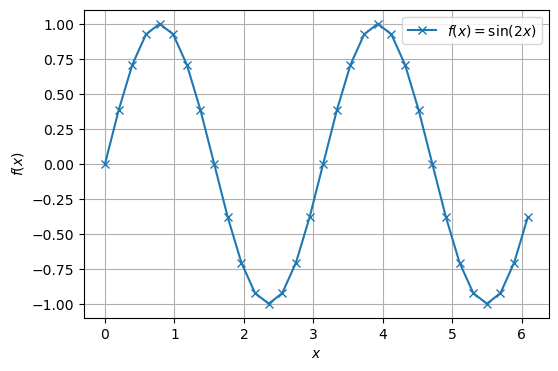

In [2]:
# define domain but throw the end point out
x = torch.linspace(0, 2*torch.pi, 33)
zi = 1j  # define imaginary number
x = x[:-1]

f = torch.sin(2*x)

fig = plt.figure(figsize=(6, 4))
ax = plt.axes()
ax.plot(x, f, 'x-', label=r"$f(x) = \sin(2x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.legend()
ax.grid();

Since $\mathrm{e}^{2\mathrm{i}x} = \cos(2x) + \mathrm{i}\sin(2x)$, convince yourself that the above function $f(x) = \sin(2x)$ should only have non-zero entries for the imaginary components in the Fourier representation. In the below I call the FFT command via `torch.fft.fft` to generate the transformed data, and plot out the real part, the imaginary part of the coefficients as well as what is called the ***power spectrum*** (or the ***power spectrum density***, or PSD), which is just $|c_k|^2$.

By default this gives data for positive and negative $k$ entries, and we can generate the appropriate $k$s with `torch.fft.fftfreq` (with a multiplicative factor to turn it from a frequency back into a wavenumber).

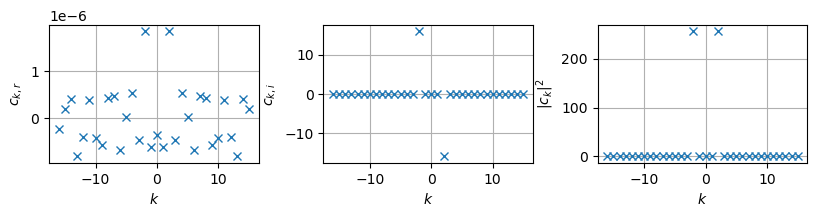

In [3]:
f_h = torch.fft.fft(f)
k = torch.fft.fftfreq(len(f_h)) * len(f_h)

fig = plt.figure(figsize=(8, 2))
ax = plt.subplot(1, 3, 1)
ax.plot(k, f_h.real, 'x')
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$c_{k,r}$")
ax.grid()

ax = plt.subplot(1, 3, 2)
ax.plot(k, f_h.imag, 'x')
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$c_{k,i}$")
ax.grid()

ax = plt.subplot(1, 3, 3)
ax.plot(k, torch.abs(f_h)**2, 'x')
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$|c_k|^2$")
ax.grid();

plt.tight_layout(pad=0.1);

As advertised there are only significantly non-zero entries in the imaginary part for $k=\pm2$, and all others are essentially noise. Note for this example the distribution of the coefficients' real part is symmetric about $k=0$, but anti-symmetric about $k=0$ for the imaginary part.

> <span style="color:red">Q.</span> Convince yourself if you included the end point then the plots become "wrong".
> 
> <span style="color:red">Q.</span> Try swapping out the sine with a cosine instead and see if the observations about the symmetries change (your power spectrum should be the same if you kept the wavenumber the same). Have a think why there those symmetries should arise.
> 
> <span style="color:red">Q.</span> Instead of swapping out the sine function, add a sine and/or cosine of a different magnitude and a different wavenumber in and plot out what the function looks like in $x$ (i.e. in real space), as well as what it looks like in $k$ (in spectral space). This hopefully convinces you why Fourier analysis is an incredibly useful thing to do when you are dealing with periodic signals.

There are various things one could do to the function in spectral space which has an impact on its representation in real space, and vice-versa. The first example is if I start manipulating some coefficients as I do below: the result is a shift by a quarter of a wavelength.

> <span style="color:red">Q.</span> Have a think what the code is doing and why we should get what we got. Note this relates to the second question above.

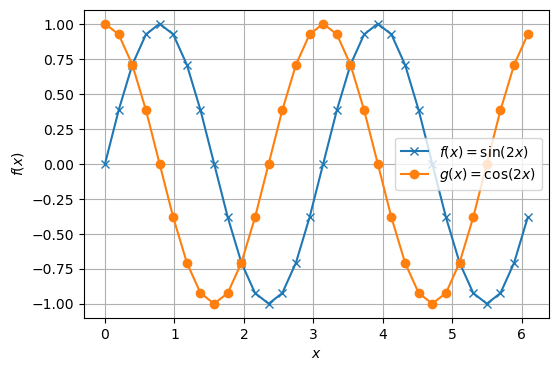

In [4]:
# shift it to get cosine

g_h = f_h[:]
g_h[k>=0] *= 2.0*zi
g_h[:].imag = 0.0
g = torch.fft.ifft(g_h).real

fig = plt.figure(figsize=(6, 4))
ax = plt.axes()
ax.plot(x, f, 'x-', label=r"$f(x) = \sin(2x)$")
ax.plot(x, g, 'o-', label=r"$g(x) = \cos(2x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.legend()
ax.grid();

Another thing I could do is to multiply all the coefficients by $\mathrm{i}k$ and $(\mathrm{i}k)^2 = -k^2$, which ends up taking ***derivatives*** of the function. The reason for this is because
\begin{equation*}
    \frac{\mathrm{d}}{\mathrm{d} x} f(x) = \frac{\mathrm{d}}{\mathrm{d} x} \sum_{k=-\infty}^\infty c_k \mathrm{e}^{\mathrm{i}kx} = (\mathrm{i}k) \sum_{k=-\infty}^\infty c_k \mathrm{e}^{\mathrm{i}kx} = (\mathrm{i}k) f(x),
\end{equation*}
i.e. differentiation becomes a multiplication by $\mathrm{i}k$ in spectral space.

> NOTE: This is called ***spectral differentiation***, and is what the `scipy.fftpack import diff as psdiff` line in the KdV calculation from `07_RNN` (and below) is doing under the hood (sort of).

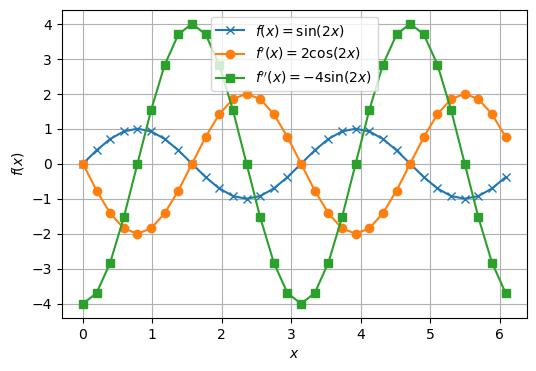

In [5]:
# take some derivatives

df_h = (zi*k) * f_h
d2f_h = (-k**2) * f_h
df = torch.fft.ifft(df_h).real
d2f = torch.fft.ifft(d2f_h).real

fig = plt.figure(figsize=(6, 4))
ax = plt.axes()
ax.plot(x, f, 'x-', label=r"$f(x) = \sin(2x)$")
ax.plot(x, df, 'o-', label=r"$f'(x) = 2\cos(2x)$")
ax.plot(x, d2f, 's-', label=r"$f''(x) = -4\sin(2x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.legend()
ax.grid();

There are other operations that can be done (e.g. integration would be dividing by $\mathrm{i}k$ but taking careful of the $k=0$ case, which corresponds to the constant of integration). The main one we need for FNOs is from the [***spectral convolution theorem***](https://en.wikipedia.org/wiki/Convolution_theorem), which states that *convolution in spectral space is a pointwise multiplication in real space, and vice-versa*.

Then FNOs have a very close link with CNNs: FNOs is kind of like a CNNs with a domain-size kernel (because the Fourier expansion is "global"), and anything a CNN can do the FNO can also do in principle. Further, since we can train CNNs with some machinery, we can train FNOs with the same machinery if we know how to transform the data accordingly (which we now do).

### Fourier layers

The Fourier layer effectively is given schematically below (image from Fig. 2 of Li et al; 2021).

<img src="https://i.imgur.com/iIPA460.jpeg" width="600" alt='Fourier layer'>

The algorithm is as follows:

1. Lift data with input dimension `in_channels` up to a higher number channels
   - this is called ***lifting layer***, with the result represented as $v(x)$ above
   - usually via a MLP where the resulting number of channels is related to the `width` variable below
   - want this to be reasonably large
2. Two parts here:
   - (Upper route) Fourier transform, learning some weights (the $R$ in the schematic, number of modes relate to `modes` in code below), multiply in spectral space (`compl_mul1d` below), inverse transform back to real space
     - this will be the `SpecConv1d` class below
     - remember multiplication in spectral space is a convolution in real space
     - don't want `modes` too small (things are too smooth) or too close to the ***Nyquist frequency*** probably (small-scale details alias back onto the low modes when mode mixing)
   - (Lower route) Do some ***mode mixing*** for nonlinearities (this is the $W$ in the schematic)
     - this would be done as a MLP if we did it in spectral space, but is done as a convolution in real space, and is the `Conv1d` in the `FNO1d` class below
3. Add the two parts up (the $+$) and do nonlinear activation (the $\sigma$) on that
   - this is the `gelu` below (***Gaussian Error Linear Units***)
4. Stack the layers for added complexity. Once we are done, project it back down to the output dimension `out_channels`

The below code block first shows the $R$ part first, because that's the thing which is not entirely obvious.

> NOTE: I originally used the code from the paper of [Pahlavan et al (2025)](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024GL114136?af=R) for reference purposes. I defaulted back to Zongyi Li's implementation (see [here](https://github.com/li-Pingan/fourier-neural-operator/blob/main/fourier_2d_time.py)).
>
> The FFT operation used here is actually `torch.fft.rfft` and the relevant inverse, which is defined for data that are completely real (which ours are), and the only difference with `torch.fft.fft` is that it doesn't give you the negative wavenumbers.

In [6]:
# spectral convolution class

class SpecConv1d(nn.Module):

    # FFT, linear transform, then IFFT
    
    def __init__(self, 
                 in_channels, 
                 out_channels, 
                 modes):
        super(SpecConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.scale = (1 / (in_channels*out_channels))
        self.weights = nn.Parameter(self.scale * torch.rand(in_channels, 
                                                            out_channels, 
                                                            self.modes, 
                                                            dtype=torch.cfloat)
                                   )

    # define multiplication in spectral space accordingly
    def compl_mul1d(self, input, weights):
        # syntax below to do multiply data ("einsum" = Einstein summation)
        #   input data of shape (b, i, x)
        #   weights (to be learned) of shape (i, o, x)
        #   output of shape (b, i, x) * (i, o, x) -> (b, o, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batchsize = x.shape[0]
        
        x_h = torch.fft.rfft(x)

        # initialise in Fourier space on the right device and dump into the intended dimension
        out_h = torch.zeros(batchsize, 
                            self.out_channels, 
                            x.size(-1)//2 + 1,
                            device=x.device, dtype=torch.cfloat)
        out_h[:, :, :self.modes] = self.compl_mul1d(x_h[:, :, :self.modes], self.weights)

        x = torch.fft.irfft(out_h, n=x.size(-1))
        
        return x

Next part is the FNO model itself called `FNO1d`. Various things to note here:

* The input data is assumed to be in the channel first convention of PyTorch (unlike the other people's implementations), so for the 1d case it will be `(b[atch], c[hannel], w[idth])`.
  - this "width" (which I denote `w`) is in terms of how many space points there are, not to be confused with `width` or `self.width` in the code below, which is the number of intermediate channels...
* The lifting layer transforms the `c` dimension from `in_channels+1` to `self.width`.
  - there is a `+1` because the grid information (with the `get_grid` subroutine) stating the distribution of data is going to be embedded and passed on as feature for the training to provide some data distribution information
  - we assume the data is distributed uniformly, which you need for the Fourier representation (so FNOs)
* There are quite a few `x.permute(0, 2, 1)` operations to make sure we are acting on the right dimenions.
  - concatenation is in the last dimension and should be done on `c`
  - the MLPs act on `c` in the last position
  - the convolution `conv0` and mode mixing `w0` act on `w` the channel in the last position

In [7]:
class FNO1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes, width):
        super(FNO1d, self).__init__()
        
        self.modes = modes
        self.width = width

        # lifting: (in_channels+1 -> num_channels; +1 because going to embed 1d grid in)
        self.fc0 = nn.Linear(in_channels+1, self.width)

        # FNO parts: num_channels -> num_channels but with mode multiplication
        self.conv0 = SpecConv1d(self.width, self.width, self.modes)
        self.w0 = nn.Conv1d(self.width, self.width, 1)

        # projecting: (num_channels -> 128 -> out_channels)
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, out_channels)

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

    def forward(self, x):
        # lifting layer
        x = x.permute(0, 2, 1)  # (b, c, w) -> (b, w, c)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)  # bulk out (..., c)
        x = self.fc0(x)
        x = x.permute(0, 2, 1)  # (b, w, c) -> (b, c, w)

        # FNO block
        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = x1 + x2
        x = F.gelu(x)  # Gaussian Error Linear Unit

        # projection layer
        x = x.permute(0, 2, 1)  # (b, c, w) -> (b, w, c)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        x = x.permute(0, 2, 1)  # (b, w, c) -> (b, c, w)
        
        return x

One concern you may have is that the Fourier basis is technically for periodic functions, so if we don't have periodicity this may be an issue. As described above, this could be done with extra ***padding*** (which was an option for convolution layers for different reasons). This I don't put into the above since the two of three examples I put below are periodic by design, but it is in there for the `FNO2d` case at the end.

---
## b) `FNO1d` on a linear PDE example

We first deal with the diffusion equation, which is a linear PDE. The thing we are going to do is to learn the mapping
\begin{equation*}
    u(t) \to u(t + \Delta t)
\end{equation*}
where $\Delta t$ is the time-step size; this is the same problem considered in `07_RNN`, but the machinery is different here because my FNO does not have a memory block (but is a thing you can build in, e.g. ***RNOs***). For this particular case we do in fact know the answer already: the diffusion equation when discretised might look like
\begin{equation*}
    \frac{u(t+\Delta t) - u(t)}{\Delta t} \approx \kappa\frac{\partial^2 u(t)}{\partial x^2}
\end{equation*}
which gives us
\begin{equation*}
    u(t+\Delta t) \approx \mathcal{L}u(t) =  \left(1 + \Delta t \kappa\frac{\partial^2}{\partial x^2}\right)u(t).
\end{equation*}
In spectral space we know this is basically $1 - k^2 \kappa \Delta t$; different time discretisations will give different operators. Here we are just going to fall back to the FNO to see what it would output; I suppose you can probably look into the model weights to see what training decided to result in.

> NOTE: The above uses Forward Euler discretisation, and is known to not be very stable unless your $\Delta t$ is really small. In the below I do nothing of the sort however, because I have an analytical solution to generate my data.

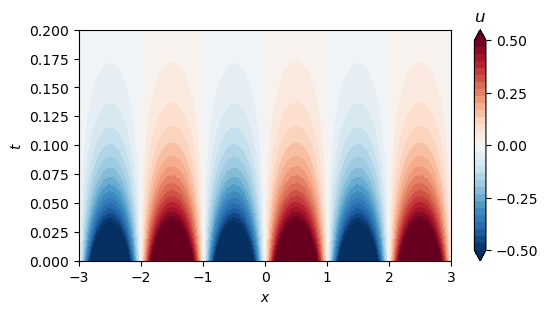

In [8]:
# plot the analytical solution to the heat/diffusion equation
def u(x, t):
    return np.exp(-2*np.pi*np.pi*t)*np.sin(np.pi*x)

nt, nx = 200, 64
t = np.linspace(0.2, 0, nt)
x = np.linspace(-3, 3, nx)

X, T = np.meshgrid(x, t)
U = u(X, T)

fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
cs = ax.contourf(x, t, U, cmap="RdBu_r",
                 levels=np.linspace(-0.5, 0.5, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([-0.5, -0.25, 0, 0.25, 0.5])
cax.ax.set_title(r"$u$");

For batching I can again use `Dataset` and `DataLoaders`. Here I don't bother with defining a custom class and go straight to it with `TensorDataset` directly. The only thing I do for defining the output dataset is to shift the input data set by one time index. I am going to train using the whole dataset for simplicity.

> NOTE: I don't train-test split or do any data scaling here. The latter in particular may be important given how different time frames have different magnitudes.
>
> There is the `num_workers=` keyword you could pass to the `DataLoader` which may help with speed of training for doing things on a GPU in terms of data loading. For this case the problem is not that big to really make a difference, but is left in for completeness.

In [9]:
# want a mapping from u(x, t) to u(x, t+1)
cutoff_ind = nt - 1

X_train = torch.from_numpy(U[0:cutoff_ind, :]).float().view(-1, 1, nx)
Y_train = torch.from_numpy(U[1:cutoff_ind+1, :]).float().view(-1, 1, nx)

train_dataset = TensorDataset(X_train, Y_train)
# num_workers=4 (for GPU things, saturating the GPU with asynchornous dataload)
train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)

The training loop is just the default one defined through a subroutine again.

> NOTE: I know I have not been consistent with variable namings and set ups for the training loops. The loops do the right thing, it's just I keep changing my mind about variable namings and loops because I sometimes just write it from scratch again, and then I forget to go back to the previous notebooks to iron things out...

In [10]:
def training_batch(model, optimizer, J, 
                   train_dataloader,
                   num_epochs=500, out_epoch=None):

    if out_epoch is None:
        out_epoch = num_epochs // 10

    # define things to dump into for loss curve
    train_J = np.zeros(num_epochs)

    for epoch in range(num_epochs):

        # reset the running loss each epoch
        running_loss = 0.0

        # iteration step (if full batch then below for loop only runs once anyway)
        for X_batch, Y_batch in train_dataloader:
            model.train()
            optimizer.zero_grad()
            Y_pred = model(X_batch.float())
            J_train = J(Y_pred.float(), Y_batch.float())
            J_train.backward()
            optimizer.step()

            # modifying the loss computation slightly
            # print(f'  Batch Loss: {J_train.item():.4f}')
            running_loss += J_train.item() * X_batch.size(0)

        train_J[epoch] = running_loss / len(train_dataloader.dataset)

        if (epoch == 0) or ((epoch+1) % out_epoch == 0):
            print(f"Epoch {epoch+1}/{num_epochs}, "
                + f"Train Loss: {train_J[epoch]:.8f}")

    return model, train_J

I go ahead to initialise a model accordingly. The two main tuning parameters are:

* `modes`, which is the number of Fourier modes that are active in the `SpecConvd1d` operation
  - this number being too small makes the predictions too smooth, because only the low frequency modes (small wavenumbers or the long wavelengths) are in play
  - this number being too large involves too many high frequencies, and errors may ***alias*** back onto the low modes
  - this number cannot be bigger than `int(input_size / 2)` because this will exceed the ***Nyquist frequency***: given the number of data points there is an upper limit to the frequency of waves that you can meaningfully represent (cf. if you only have data for ten years it is not really meaningful to talk about a decadal oscillation)
* `width`, which is the number of channels we are going to blow the data up to in the lifting layer, and is related to what the `SpecConv1d` and `Conv1d` are going to act on
  - the larger it is the more complexity there can be, but will also be slower and more expensive to train

The number of in and out channels are both `1`, because I throw a $u$ in and I want a $u$ out. Here I use `AdamW` as the optimiser, which has some default regularisation added on. I train it and plot the losses out.

> NOTE: The learning rate I took to be reasonably big: I have not personally found it made that much more difference with the skill of the task if I turned it down (but I would need more training epochs). The thing that seems to make quite a bit difference beyond the ones mentioned already is the `batch_size` that you can change when defining the `DataLoader`.
>
> You can in principle have the convolution layers changing the number of dimensions within the Fourier layers or the FNO blocks; I don't do that here because I only have one FNO block for demonstration purposes.

In [11]:
# initialise model
torch.manual_seed(666)

# tunable parameters for model complexity
modes = 8   # number of Fourier modes to multiply
width = 32  # input and output channels for the FNO layer
in_channels = 1
out_channels = 1

J = nn.MSELoss()

model = FNO1d(in_channels, out_channels, modes, width).float()
print(f"trainable parameters = {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

# learning_rate = 1e-4
learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
print(model)

model, train_J = training_batch(model, optimizer, J, 
                                train_dataloader,
                                num_epochs=100)

trainable parameters = 13697
FNO1d(
  (fc0): Linear(in_features=2, out_features=32, bias=True)
  (conv0): SpecConv1d()
  (w0): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 1/100, Train Loss: 0.04824855
Epoch 10/100, Train Loss: 0.00001172
Epoch 20/100, Train Loss: 0.00000624
Epoch 30/100, Train Loss: 0.00000545
Epoch 40/100, Train Loss: 0.00000384
Epoch 50/100, Train Loss: 0.00000219
Epoch 60/100, Train Loss: 0.00000223
Epoch 70/100, Train Loss: 0.00000102
Epoch 80/100, Train Loss: 0.00000143
Epoch 90/100, Train Loss: 0.00000163
Epoch 100/100, Train Loss: 0.00000014


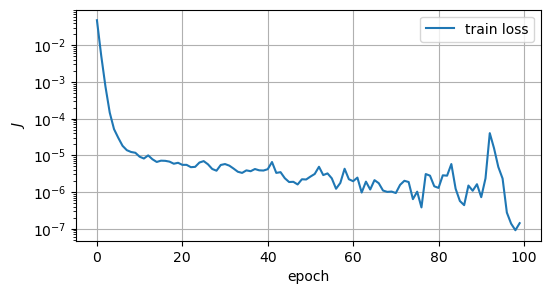

In [12]:
# plot out the losses
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.semilogy(train_J, label="train loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

First I do the "easy" test by predicting the flow at one time-step later, which I can do by comparing `U_pred = model(X_train)` (which gives me predicted data at time-stamp 1 to the end) and comparing it with the true data given by `U[1:, :]`. You can convince yourself the error is reasonably low by plotting the point-wise absolute differences (as a function of $(t, x)$), probably on a log scale to highlight the small values.

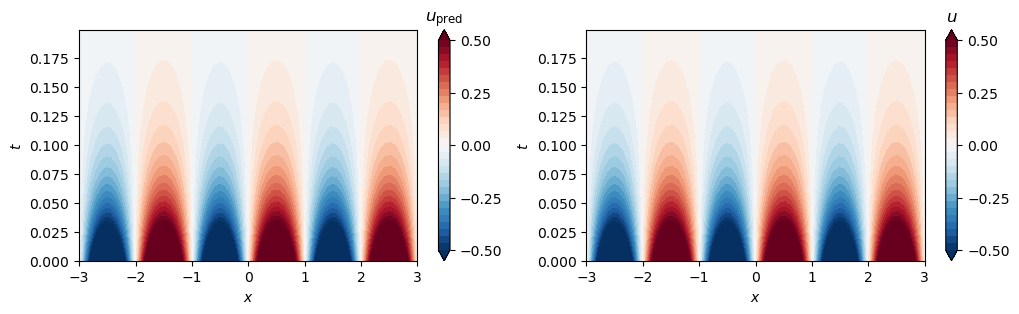

In [13]:
# prediction over the whole dataset
with torch.no_grad():
    U_pred = model(X_train)

U_pred = U_pred.squeeze().numpy()

fig = plt.figure(figsize=(12, 3))
ax = plt.subplot(1, 2, 1)
cs = ax.contourf(x, t[1:], U_pred, cmap="RdBu_r",
                 levels=np.linspace(-0.5, 0.5, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([-0.5, -0.25, 0, 0.25, 0.5])
cax.ax.set_title(r"$u_{\rm pred}$")

ax = plt.subplot(1, 2, 2)
cs = ax.contourf(x, t[1:], U[1:, :], cmap="RdBu_r",
                 levels=np.linspace(-0.5, 0.5, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([-0.5, -0.25, 0, 0.25, 0.5])
cax.ax.set_title(r"$u$");

The harder test is of course if I use the given `U[0, :]` to predict `U_pred[1, :]`, then use that to predict `U_pred[2, :]` and so forth, which is what I do below.

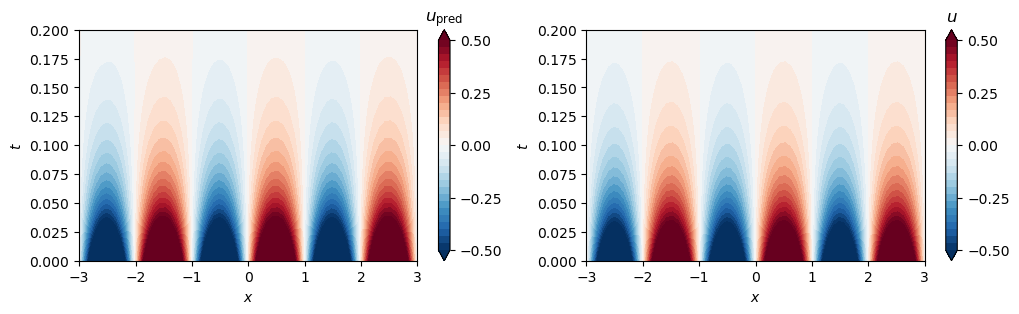

In [14]:
# sequential prediction and piggy back on initial condition

U_pred = np.zeros(U.shape)
U_pred[0, :] = U[0, :]  # initial condition
U_pred = torch.tensor(U_pred).float().view(nt, 1, nx)  # turn into form model wants

for i in range(len(t)-1):
    with torch.no_grad():
        U_pred[i+1, :, :] = model(U_pred[i, :, :].view(1, 1, nx))  # turn into form model wants

U_pred = U_pred.squeeze().numpy()

fig = plt.figure(figsize=(12, 3))
ax = plt.subplot(1, 2, 1)
cs = ax.contourf(x, t, U_pred, cmap="RdBu_r",
                 levels=np.linspace(-0.5, 0.5, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([-0.5, -0.25, 0, 0.25, 0.5])
cax.ax.set_title(r"$u_{\rm pred}$");

ax = plt.subplot(1, 2, 2)
cs = ax.contourf(x, t, U, cmap="RdBu_r",
                 levels=np.linspace(-0.5, 0.5, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([-0.5, -0.25, 0, 0.25, 0.5])
cax.ax.set_title(r"$u$");

Actually looks ok! The patterns are correct, although if you examine the pointwise errors then are not necessarily negligible.

> <span style="color:red">Q.</span> Plot the pointwise absolute errors and see if my statement above holds any truth. I would put it on a log-scale to highlight the small values.
>
> Another thing you might do is to plot the percentage error relative to the magnitude of $u$ at the point of interest; for example, an error of "1" could be "1 out of 1,000,000" or "1 out of 1", and is not small for the second case.
>
> <span style="color:red">Q.</span> The above thing "works" but it is also because I chose a combination of `seed`, `batch_size`, `modes`, `width` and `learning_rate` (models seems to converge fast enough that `num_epochs` don't seem to matter too much). Have an explore of those to see how the model fails (or improves) in the sequential prediction problem.
>
> <span style="color:red">Q.</span> I didn't scale the data or did train-test(-validation) split. Put those in and see what difference it makes. Need to have a think how you want to scale the data also.
>
> <span style="color:red">Q.</span> Previously we encountered batch normalisation, but I didn't do that here either. Have a look to see where and how you would want to put that in.
>
> <span style="color:red">Q.</span> I kept the number of FNO blocks small (1 to be precise), you could try adding more of those, although you then probably want to test this on a GPU. (Most examples I have seen use about four.)

---
## c) `FNO1d` on a non-linear PDE example

We can play exactly the same game for the KdV example we encountered in `07_RNN`. For this case we don't know the operator explicitly (not that knowing it helped really in the previous case), but we can still do exactly the same thing above, which is what is done below.

Generate the data just like the previous case before.

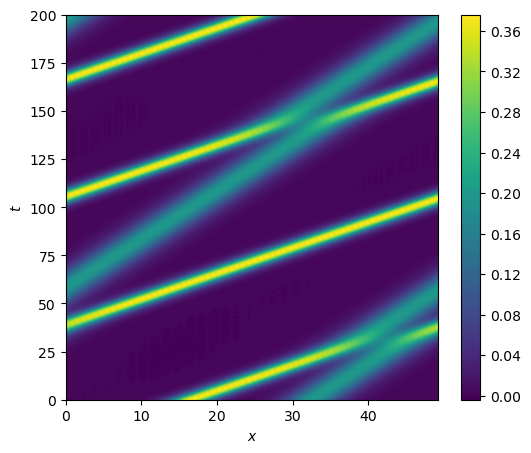

In [15]:
# brute force solve the KdV equation with two solitons initial condition (sort of)
# pseudo-spectral for periodic domain
# (taken from https://scipy-cookbook.readthedocs.io/items/KdV.html)

from scipy.integrate import odeint
from scipy.fftpack import diff as psdiff

# define the initial conditions for a single soliton, generate two of these and add them
# together
# (the two solition solution is not what is described but it's good enough...)
def kdv_exact(x, c):
    u = 0.5*c*np.cosh(0.5*np.sqrt(c)*x)**(-2)
    return u

# define the subroutine for generating \partial u / \partial t
def kdv(u, t, L):
    ux = psdiff(u, period=L)
    uxxx = psdiff(u, period=L, order=3)
    return -6*u*ux - uxxx

# set the space and time grid
L = 50.0
nx = 64
dx = L / (nx - 1.0)
x = np.linspace(0, (1-1.0/nx)*L, nx)

# set the time sample grid

T = 200
nt = 501
t = np.linspace(0, T, nt)

# initial conditions with two solitons (caveat as above
U0 = kdv_exact(x-0.33*L, 0.75) + kdv_exact(x-0.65*L, 0.4)
U = odeint(kdv, U0, t, args=(L,), mxstep=5000)

# Hovmoller plot (time going up)
fig = plt.figure(figsize=(6, 5))
ax = plt.axes()
cs = ax.contourf(x, t, U, levels=101)
cax = plt.colorbar(cs)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$t$');

Still going to throw the whole dataset in.

In [16]:
# want a mapping from u(x, t) to u(x, t+1)
cutoff_ind = nt - 1

X_train = torch.from_numpy(U[0:cutoff_ind, :]).float().view(-1, 1, nx)
Y_train = torch.from_numpy(U[1:cutoff_ind+1, :]).float().view(-1, 1, nx)

train_dataset = TensorDataset(X_train, Y_train)
# num_workers=4 (for GPU things, saturating the GPU with asynchornous dataload)
train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)

The `FNO1d` is going to have exactly the same structure, although I am going to increase the complexity by increasing the number of `modes` and `width` (double compared to the model above). Then I am going to do the same two tests.

In [17]:
# initialise model

torch.manual_seed(666)

# tunable parameters for model complexity

modes = 16  # number of Fourier modes to multiply
width = 64  # input and output channels for the FNO layer
in_channels = 1
out_channels = 1

# this one is ok then does crazy things (lr = 1e-3)
# modes = 8  # number of Fourier modes to multiply
# width = 32  # input and output channels for the FNO layer

J = nn.MSELoss()

model = FNO1d(in_channels, out_channels, modes, width).float()
print(f"trainable parameters = {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
print(model)

model, train_J = training_batch(model, optimizer, J, 
                                train_dataloader,
                                num_epochs=100)

trainable parameters = 78337
FNO1d(
  (fc0): Linear(in_features=2, out_features=64, bias=True)
  (conv0): SpecConv1d()
  (w0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 1/100, Train Loss: 0.00427477
Epoch 10/100, Train Loss: 0.00000406
Epoch 20/100, Train Loss: 0.00000186
Epoch 30/100, Train Loss: 0.00000112
Epoch 40/100, Train Loss: 0.00000180
Epoch 50/100, Train Loss: 0.00000348
Epoch 60/100, Train Loss: 0.00000195
Epoch 70/100, Train Loss: 0.00000051
Epoch 80/100, Train Loss: 0.00000142
Epoch 90/100, Train Loss: 0.00000177
Epoch 100/100, Train Loss: 0.00000028


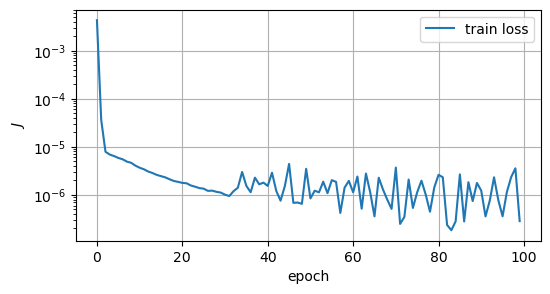

In [18]:
# plot out the losses
fig = plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.semilogy(train_J, label="train loss")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$J$")
ax.grid()
ax.legend();

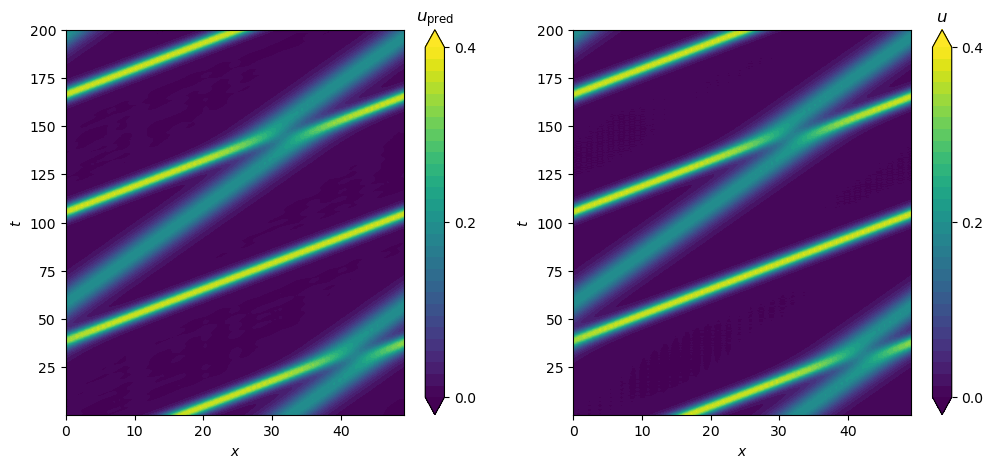

In [19]:
# prediction over the whole dataset
with torch.no_grad():
    U_pred = model(X_train)

U_pred = U_pred.squeeze().numpy()

fig = plt.figure(figsize=(12, 5))
ax = plt.subplot(1, 2, 1)
cs = ax.contourf(x, t[1:], U_pred,
                 levels=np.linspace(0.0, 0.4, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([0.0, 0.2, 0.4])
cax.ax.set_title(r"$u_{\rm pred}$")

ax = plt.subplot(1, 2, 2)
cs = ax.contourf(x, t[1:], U[1:, :],
                levels=np.linspace(0.0, 0.4, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([0.0, 0.2, 0.4])
cax.ax.set_title(r"$u$");

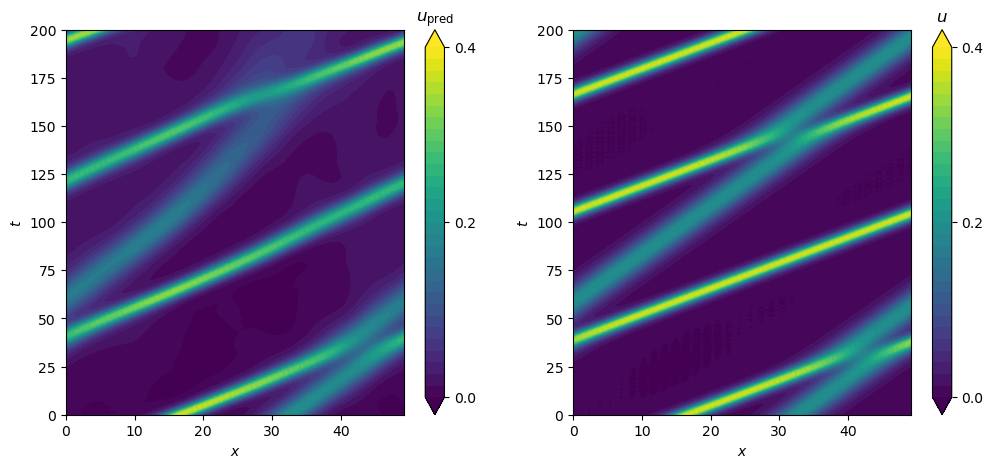

In [20]:
# sequential prediction and piggy back on initial condition

U_pred = np.zeros(U.shape)
U_pred[0, :] = U[0, :]  # initial condition
U_pred = torch.tensor(U_pred).float().view(nt, 1, nx)  # turn into form model wants

for i in range(len(t)-1):
    with torch.no_grad():
        U_pred[i+1, :, :] = model(U_pred[i, :, :].view(1, 1, nx))  # turn into form model wants

U_pred = U_pred.squeeze().numpy()

fig = plt.figure(figsize=(12, 5))
ax = plt.subplot(1, 2, 1)
cs = ax.contourf(x, t, U_pred,
                 levels=np.linspace(0.0, 0.4, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([0.0, 0.2, 0.4])
cax.ax.set_title(r"$u_{\rm pred}$")

ax = plt.subplot(1, 2, 2)
cs = ax.contourf(x, t, U,
                levels=np.linspace(0.0, 0.4, 31), extend="both")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
cax = plt.colorbar(cs)
cax.ax.set_yticks([0.0, 0.2, 0.4])
cax.ax.set_title(r"$u$");

In this case one of the solitons actually seems to disappear after a while, although the other seems "ok". Again, I've tuned this somewhat to give this vaguely presentable result, but I should also stress I've kept the networks quite shallow for demonstration reasons.

> <span style="color:red">Q.</span> Plot the pointwise absolute errors and the percentage errors. I would put it on a log-scale to highlight the small values.
>
> <span style="color:red">Q.</span> Similar exploration with `seed`, `batch_size`, `modes`, `width` and `learning_rate` (models seems to converge fast enough that `num_epochs` don't seem to matter too much). Have an explore of those to see how the model fails in the sequential prediction problem.
>
> <span style="color:red">Q.</span> I didn't scale the data or did train-test(-validation) split. Put those in and see what difference it makes. Need to have a think how you want to scale this also. Same thing with batch normalisation.
>
> <span style="color:red">Q.</span> I kept the number of FNO blocks small (1 to be precise), you could try adding more of those, although you then probably want to use this on a GPU. (Most examples I have seen use about four, but I would just try two first.)

---
## d) `FNO2d` on a non-PDE example

You could say well FNO is naturally suited to periodic things (which the above are) and for differential equations (which is probably true), so not sure why or whether you would use it for other things. Here I am going to do the cat face regression problem with FNOs to semi-demonstrate that you can basically use it like a CNN if you want to. Going to load the data first.

In [21]:
# don't read the headers

option = "remote"

if option == "local":
    print("loading data locally (assumes file has already been downloaded)")
    path = "cat.csv"
elif option == "remote":
    print("loading data remotely")
    path = "https://raw.githubusercontent.com/julianmak/OCES5303_ML_ocean/refs/heads/main/cat.csv"
else:
    raise ValueError("INVALID OPTION: use 'remote' or 'local'")

df_cats = pd.read_csv(path, header=None).T # make "features" the axis=-1
X_cats = df_cats.values / 255 # normalise

loading data remotely


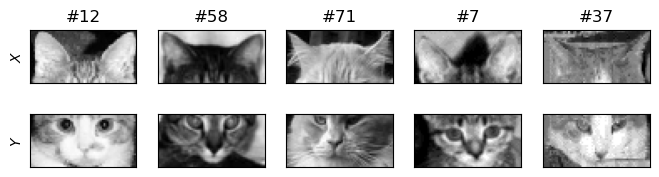

In [22]:
def split_top_bottom(data):
    n, width = data.shape[0], int(np.sqrt(data.shape[1]))
    data = np.reshape(data, (n, width, width))
    top_half, bottom_half = data[:, :, 0:width//2], data[:, :, width//2::]
    top_half = np.reshape(top_half, (n, width*width//2))
    bottom_half = np.reshape(bottom_half, (n, width*width//2))

    return top_half, bottom_half

X_train, Y_train = split_top_bottom(X_cats)

# quick plots to see the images
ind = np.arange(X_train.shape[0])
np.random.shuffle(ind)  # syntax for shuffle: not used like a function with input output...

# sample show (on-the-fly reshape data)
fig = plt.figure(figsize=(8, 2))
for i in range(5):
    ax = plt.subplot(2, 5, i+1)
    ax.imshow(np.reshape(X_train[ind[i], :], (64, 32)).T, cmap="gray")
    ax.set_title(f"#{ind[i]}")
    if i == 0:
        ax.set_ylabel("$X$")
    ax.set_xticks([]); ax.set_yticks([]);

    ax = plt.subplot(2, 5, i+1+5)
    ax.imshow(np.reshape(Y_train[ind[i], :], (64, 32)).T, cmap="gray")
    if i == 0:
        ax.set_ylabel("$Y$")
    ax.set_xticks([]); ax.set_yticks([]);

I am going to be lazy and throw all the data in again. What I do os like in `05_CNN` to reshape the data into the appropriate sizes first, in this case as `(batch, channel, height, width)` (or `(..., width, height)`, doesn't really matter). The channel dimension is `1` because this is a greyscale image. Going to pass this to a `DataLoader` again, and I choose a reasonably small batch size.

In [23]:
X_train = X_train.reshape(-1, 1, 64, 32)
Y_train = Y_train.reshape(-1, 1, 64, 32)

train_dataset = TensorDataset(torch.from_numpy(X_train).float(), 
                              torch.from_numpy(Y_train).float())
# num_workers=4 (for GPU things, saturating the GPU with asynchornous dataload)
train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)

The below is the 2d analogue of the `SpecConv1d` above. The only difference is that we have `modes1` and `modes2` and some extra operations to deal with the extra dimension.

In [24]:
class SpecConv2d(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 modes1,
                 modes2):
        super(SpecConv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, 
                                                             out_channels, 
                                                             self.modes1, 
                                                             self.modes2, 
                                                             dtype=torch.cfloat)
                                    )
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, 
                                                             out_channels, 
                                                             self.modes1, 
                                                             self.modes2, 
                                                             dtype=torch.cfloat)
                                    )

    def compl_mul2d(self, input, weights):
        # syntax below to do multiply data ("einsum" = Einstein summation)
        #   input data of shape (b, i, x, y)
        #   weights (to be learned) of shape (i, o, x, y)
        #   output of shape (b, i, x, y) * (i, o, x, y) -> (b, o, x, y)
        return torch.einsum("bixy,ioxy->boxy", input, weights)
        
    def forward(self, x):
        
        batchsize = x.shape[0]
        
        x_h = torch.fft.rfft2(x)

        out_h = torch.zeros(batchsize, 
                            self.out_channels,  
                            x.size(-2), 
                            x.size(-1)//2 + 1, 
                            dtype=torch.cfloat, device=x.device)
        out_h[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_h[:, :, :self.modes1, :self.modes2], self.weights1)
        out_h[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_h[:, :, -self.modes1:, :self.modes2], self.weights2)

        x = torch.fft.irfft2(out_h, s=(x.size(-2), x.size(-1)))
        
        return x

The below is the analogue of `FNO1d` above, where we have extra operations and extra bits with `.permute()` to deal with the channel dimension. An extra thing added here is the `padding`, the `F.pad()` operation (acting only on the two space dimensions), and then removing that padding at the projecting step, which is designed to deal with non-periodicity.

In [25]:
class FNO2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, width):
        super(FNO2d, self).__init__()
        
        self.modes1 = modes1
        self.modes2 = modes2
        self.width  = width
        self.padding = 9 # pad the domain if input is non-periodic

        self.fc0 = nn.Linear(in_channels+2, self.width)

        # num_channels -> num_channels but with mode multiplication
        self.conv0 = SpecConv2d(self.width, self.width, self.modes1, self.modes2)
        self.bn = nn.BatchNorm2d(self.width)
        self.w0 = nn.Conv2d(self.width, self.width, 1)

        # num_channels -> 128 -> 1 output
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, out_channels)

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1).to(device)

    def forward(self, x):

        x = x.permute(0, 2, 3, 1)  # (b, c, w, h) -> (b, w, h, c)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)  # bulk out (..., c)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)  # (b, w, h, c) -> (b, c, w, h)
        x = F.pad(x, [0, self.padding, 0, self.padding])  # pad last two dimensions

        x1 = self.conv0(x)
        # x1 = self.bn(x1)  ## ???
        x2 = self.w0(x)
        x = x1 + x2
        x = F.gelu(x)  # Gaussian Error Linear Unit

        x = x[..., :-self.padding, :-self.padding]
        x = x.permute(0, 2, 3, 1)  # (b, c, w, h) -> (b, w, h, c)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        x = x.permute(0, 3, 1, 2)  # (b, w, h, c) -> (b, c, w, h)
        
        return x

We proceed to initialise the model and train it again. 

> NOTE: Below is a bit slow because I find you need a sizeable number of epochs to get a result I can say something about (see later). This may want to be done on a GPU; on my laptop it takes maybe 10 mins or so to do the 300 epoch training.
>
> I also find I need the number of modes to be reasonably high. It may be that for this image regression problem I am dealing with quite a lot of small-scale features, who knows...

In [26]:
# initialise model and train

torch.manual_seed(666)

# tunable parameters for model complexity (16, 16, 32) works ok for train set
modes1 = 16  # number of Fourier modes to multiply
modes2 = 16  # number of Fourier modes to multiply
width = 32   # input and output channels for the FNO layer

J = nn.MSELoss()

model = FNO2d(1, 1, modes1, modes2, width).float()
print(f"trainable parameters = {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
print(model)

model, train_J = training_batch(model, optimizer, J, 
                                train_dataloader,
                                num_epochs=300)

trainable parameters = 529889
FNO2d(
  (fc0): Linear(in_features=3, out_features=32, bias=True)
  (conv0): SpecConv2d()
  (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (w0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 1/300, Train Loss: 0.14565042
Epoch 30/300, Train Loss: 0.04099591
Epoch 60/300, Train Loss: 0.03524375
Epoch 90/300, Train Loss: 0.02950150
Epoch 120/300, Train Loss: 0.02440683
Epoch 150/300, Train Loss: 0.02054534
Epoch 180/300, Train Loss: 0.01755167
Epoch 210/300, Train Loss: 0.01586628
Epoch 240/300, Train Loss: 0.01469677
Epoch 270/300, Train Loss: 0.01303403
Epoch 300/300, Train Loss: 0.01144439


Going to evaluate this on the same dataset given above.

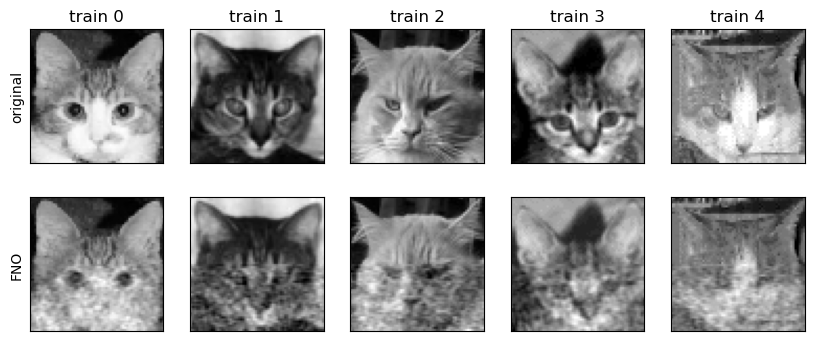

In [27]:
X_train_plot = train_dataset[:][0].squeeze().numpy()
Y_train_plot = train_dataset[:][1].squeeze().numpy()

# do the lazy thing and predict everything, then pull out individual bits
with torch.no_grad():
    Y_pred = model(train_dataset[:][0]).squeeze().numpy()

fig, ax = plt.subplots(figsize=(10, 4), nrows=2, ncols=5)

for j in range(0, 5):
    ax[0][j].imshow(np.hstack((X_train_plot[ind[j], :, :], 
                               Y_train_plot[ind[j], :, :])).T, 
                    cmap="gray")
    ax[0][j].set_title(f"train {j}")
    
    ax[1][j].imshow(np.hstack((X_train_plot[ind[j], :, :], 
                               Y_pred[ind[j], :, :])).T, 
                    cmap="gray")

for i in range(2):
    for j in range(5):
        ax[i][j].set_xticks([]); ax[i][j].set_yticks([]);
        if j == 0:
            ax[0][j].set_ylabel("original")
            ax[1][j].set_ylabel("FNO")

If you squint your eyes a bit you might argue that the FNO may have potential if you give it a bit more complexity? The face shape is sort of there, there are hints of the eyes and the nose, and the pattern seems to be there. Of course this is a test done on the train set, so that itself may not be saying much, but the FNO is shallow, my datasize is reasonably small also, and the regression problem for images is a hard problem...

Just for fun, we can deploy the trained FNO on the ad hoc TAs and see how well or badly it does.

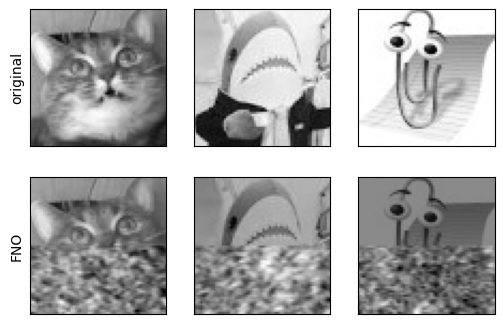

In [28]:
import requests
from PIL import Image
from io import BytesIO

targets_path = {
    "miffy_gormless" : "https://raw.githubusercontent.com/julianmak/OCES5303_ML_ocean/refs/heads/main/miffy_gormless.jpg",
    "blauhaj" : "https://raw.githubusercontent.com/julianmak/OCES5303_ML_ocean/refs/heads/main/blauhaj.jpg",
    "clippy" : "https://raw.githubusercontent.com/julianmak/OCES5303_ML_ocean/refs/heads/main/clippy.jpg",
}

targets = {}

for file_name, file_url in targets_path.items():
    response = requests.get(file_url)
    targets[file_name] = Image.open(BytesIO(response.content))

# load data and normalise in the same way as cats pictures
data = np.zeros((3, 64**2))
for i, key in enumerate(targets):
    data[i, :] = np.array(targets[key]).T.flatten()
data /= 255

X_train, Y_train = split_top_bottom(data)
X_train = torch.from_numpy(X_train.reshape(-1, 1, 64, 32)).float()
Y_train = torch.from_numpy(Y_train.reshape(-1, 1, 64, 32)).float()  # not really necessary

with torch.no_grad():
    Y_pred = model(X_train).squeeze().numpy()

X_train_plot = X_train.squeeze().numpy()
Y_train_plot = Y_train.squeeze().numpy()

fig, ax = plt.subplots(figsize=(6, 4), nrows=2, ncols=3)

for j in range(0, 3):
    ax[0][j].imshow(np.hstack((X_train_plot[j, :, :], 
                               Y_train_plot[j, :, :])).T, 
                    cmap="gray")
    
    ax[1][j].imshow(np.hstack((X_train_plot[j, :, :], 
                               Y_pred[j, :, :])).T, 
                    cmap="gray")

for i in range(2):
    for j in range(3):
        ax[i][j].set_xticks([]); ax[i][j].set_yticks([]);
        if j == 0:
            ax[0][j].set_ylabel("original")
            ax[1][j].set_ylabel("FNO")

Mostly just noise here, but that may not be surprising... Again, same caveats about complexity of model and dataset size/quality apply here.

> <span style="color:red">Q.</span> Do the usual explorations maybe. You may want to use a GPU with this.
>
> You may also want to have a look at one of the extended exercises regarding the use of another package to do your FNO exploration.

There are quite a lot of other things one could do, and extensions based on the previous sessions (e.g. adding hidden states, doing physics informed constraints), some of which are suggested in the extended exercises below.

----------------
# More involved exercises with this notebook

## 1) Multiple channels of input/output

In the above examples we do one feature in and one feature out. You may try and consider doing something with multiple inputs and/or outputs. 

One simple example might be to compute the $z$-component of the vorticity from the horizontal velocity, i.e.
\begin{equation*}
    \omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y},
\end{equation*}
so the input has two channels with $(u,v)$, and the output has one channel given by $\omega$. Here you would choose some sensible velocity fields (or take it from some data source), do your own numerical computations for $\omega$, then train the FNO. You could also reverse that and throw in $\omega$ to spit out $(u,v)$ I suppose (in practice you might need a constraint for doing that integration process, but the FNO might also learn that or just pick one out, who knows).

Other examples might involving mapping some set of biogeochemistry to some physical variables, other biogeochemistry variables, or others. You could also try and get the FNO to take in multiple time-frames of the diffusion or KdV output and return multiple time-frames of the solution also.

## 2) Resolution invariance of FNOs

One thing that is part of FNOs but is not something I demonstrated is ***resolution invariance***. One thing you may have noticed is that the input only cares about the number of channels of the input data, and infers the spectral space information from the input data size via the concatenation of the grid within the FNO block itself. What that means is the learned model should be independent on the resolution in principle (although I have my doubts for its deployment in practice, particularly when there are substantial nonlinearities inherent to the data).

The data I've given above is probably not that well suited to test resolution invariance, but here are some suggestions to try:

1. The KdV problem may be ok, and you can try changing the time and/or space resolution, generate some $u$ by solving the problem again, and try the mapping in time problem again.
2. The diffusion problem I am not sure, because it will diffuse to zero presumably given long enough time-scales. I suppose one thing you can do is to choose a different initial condition (but probably for fixed `\kappa`), generate the $u$ again (time-stepping it or otherwise), and see if the FNO is able to reproduce the diffusion accordingly.
3. Better examples would be elliptic problems like ***Poisson equations***, where you want to solve $\nabla^2 u = f(x,y)$, and what you want is to take $f$ as the input and train the FNO to give you the resulting $u(x,y)$. Train it on a some choices of $f$ and see if it generalises to the same $f$ but on different resolutions, as well as different $f$s. Again, you would need to find a way to generate your data for this.

> NOTE: The `NeuralOperator` package mentioned below uses the ***Darcy flow*** problem, which is more interesting because the mapping is nonlinear (the Poisson one above is a linear PDE). You could probably modify whatever is given there for the Darcy flow problem to give you a solver for the Poisson-like equation actually.

***Stommel's problem*** for a wind-driven gyre might be a good one? Here you want to predict a wind stress profile $\tau$ and return a streamfunction profile $\psi$. An interesting one of course is if you do it the other way round: for given $\psi$, infer for the $\tau$ you need to generate it. This would be the ***inference*** problem, and could be done for the cases mentioned above also.

## 3) `NeuralOperator` package

[`NeuralOperator`](https://github.com/neuraloperator/neuraloperator) is a package that groups up the various known FNOs in a much tidier fashion than what was done above. Underneath it leverages the `PyTorch` engine, which is consistent with what we have been using. Try repeating some of the things above; see the link for how to install it.

I would use that because the interfacing with GPUs should already be part of the package. Additionally it will be much tidier and easier for doing hyper-parameter tuning and exploring the changes with complexity of the neural operator architecture. 

> NOTE: My implementations don't use the package because it was informative for me personally to try and copy-and-paste + edit things accordingly to learn about what goes on with making things the lower level way to see what is under the hood and connect the theory with the code.

## 4) RNO, PINO etc.

The neural operators have variants such as ***Recurrent Neural Operator*** (RNOs; cf. RNNs), ***Physics Informed Neural Operators*** (PINOs; cf. PINNs) and others, some of which may could be deployed for the aforementioned problems. If you have time have a look at that maybe; I would use the `NeuralOperator` package for that.